In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.colors
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [5]:
import pandas as pd
accident =  pd.read_csv('RTA_cleaned.csv')

In [6]:
accident.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Cause_of_accident,Accident_severity
0,2024-10-05 17:02:00,Monday,18-30,Male,Above high school,1-2yr,Automobile,Owner,Above 10yr,No defect,...,Collision with roadside-parked vehicles,2,2,Going straight,NaN,NaN,NaN,NaN,Moving Backward,Slight Injury
1,2024-10-05 17:02:00,Monday,31-50,Male,Junior high school,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,...,Vehicle with vehicle collision,2,2,Going straight,NaN,NaN,NaN,NaN,Overtaking,Slight Injury
2,2024-10-05 17:02:00,Monday,18-30,Male,Junior high school,1-2yr,Lorry (41-100Q),Owner,Unknown,No defect,...,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3.0,Changing lane to the left,Serious Injury
3,2024-10-05 01:06:00,Sunday,18-30,Male,Junior high school,5-10yr,Public (> 45 seats),Governmental,Unknown,No defect,...,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3.0,Changing lane to the right,Slight Injury
4,2024-10-05 01:06:00,Sunday,18-30,Male,Junior high school,2-5yr,Other,Owner,5-10yrs,No defect,...,Vehicle with vehicle collision,2,2,Going straight,NaN,NaN,NaN,NaN,Overtaking,Slight Injury


In [7]:
accident.shape

(12296, 28)

In [8]:
accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12296 entries, 0 to 12295
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Time                         12296 non-null  object 
 1   Day_of_week                  12296 non-null  object 
 2   Age_band_of_driver           12296 non-null  object 
 3   Sex_of_driver                12296 non-null  object 
 4   Educational_level            12296 non-null  object 
 5   Driving_experience           12296 non-null  object 
 6   Type_of_vehicle              12296 non-null  object 
 7   Owner_of_vehicle             12296 non-null  object 
 8   Service_year_of_vehicle      12296 non-null  object 
 9   Defect_of_vehicle            12296 non-null  object 
 10  Area_accident_occured        12296 non-null  object 
 11  Lanes_or_Medians             12296 non-null  object 
 12  Road_allignment              12296 non-null  object 
 13  Types_of_Junctio

In [9]:
accident.duplicated().sum()

0

In [10]:
accident.isna().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level                 0
Driving_experience                0
Type_of_vehicle                   0
Owner_of_vehicle                  0
Service_year_of_vehicle           0
Defect_of_vehicle                 0
Area_accident_occured             0
Lanes_or_Medians                  0
Road_allignment                   0
Types_of_Junction                 0
Road_surface_type                 0
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision                 0
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                  0
Casualty_class                 4435
Sex_of_casualty                4435
Age_band_of_casualty           4435
Casualty_severity              4435
Cause_of_accident                 0
Accident_severity           

In [11]:
print('Percentage of NaN in:')
for i in accident.columns.to_list():
    print(f'{i:<30} {100*(1-(accident[i].count()/accident.Time.count())):.3f}%')

Percentage of NaN in:
Time                           0.000%
Day_of_week                    0.000%
Age_band_of_driver             0.000%
Sex_of_driver                  0.000%
Educational_level              0.000%
Driving_experience             0.000%
Type_of_vehicle                0.000%
Owner_of_vehicle               0.000%
Service_year_of_vehicle        0.000%
Defect_of_vehicle              0.000%
Area_accident_occured          0.000%
Lanes_or_Medians               0.000%
Road_allignment                0.000%
Types_of_Junction              0.000%
Road_surface_type              0.000%
Road_surface_conditions        0.000%
Light_conditions               0.000%
Weather_conditions             0.000%
Type_of_collision              0.000%
Number_of_vehicles_involved    0.000%
Number_of_casualties           0.000%
Vehicle_movement               0.000%
Casualty_class                 36.069%
Sex_of_casualty                36.069%
Age_band_of_casualty           36.069%
Casualty_severity        

In [12]:
print(accident['Area_accident_occured'].value_counts())
print()
print(accident['Weather_conditions'].value_counts())

Other                  4080
Office areas           3451
Residential areas      2060
Church areas           1060
Industrial areas        456
School areas            415
Recreational areas      328
Outside rural areas     218
Hospital areas          121
Market areas             63
Rural village areas      44
Name: Area_accident_occured, dtype: int64

Normal               10047
Raining               1330
Other                  587
Cloudy                 124
Windy                   97
Snow                    61
Raining and Windy       40
Fog or mist             10
Name: Weather_conditions, dtype: int64


In [16]:
# clean Area_accident_occured value formatting (inspection result no. 7)
accident['Area_accident_occured'] = accident['Area_accident_occured'].str.strip()

# there are still error with merged place name (Rural village areasOffice areas)
accident = accident[accident['Area_accident_occured'] != 'Rural village areasOffice areas']
accident['Area_accident_occured'].value_counts()

Other                  4080
Office areas           3451
Residential areas      2060
Church areas           1060
Industrial areas        456
School areas            415
Recreational areas      328
Outside rural areas     218
Hospital areas          121
Market areas             63
Rural village areas      44
Name: Area_accident_occured, dtype: int64

In [17]:
# change ? to strip (-)
accident['Type_of_vehicle'] = accident['Type_of_vehicle'].str.strip()

accident['Type_of_vehicle'].mask(accident['Type_of_vehicle'] == 'Lorry (41?100Q)', 'Lorry (41-100Q)', inplace=True)
accident['Type_of_vehicle'].mask(accident['Type_of_vehicle'] == 'Lorry (11?40Q)', 'Lorry (11-40Q)', inplace=True)
accident['Type_of_vehicle'].mask(accident['Type_of_vehicle'] == 'Public (13?45 seats)', 'Public (13-45 seats)', inplace=True)

In [18]:
accident['Driving_experience'].mask(accident['Driving_experience'] == 'unknown', 'Unknown', inplace=True)
accident['Lanes_or_Medians'].mask(accident['Lanes_or_Medians'] == 'other', 'Other', inplace=True)

In [19]:
accident.isna().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level                 0
Driving_experience                0
Type_of_vehicle                   0
Owner_of_vehicle                  0
Service_year_of_vehicle           0
Defect_of_vehicle                 0
Area_accident_occured             0
Lanes_or_Medians                  0
Road_allignment                   0
Types_of_Junction                 0
Road_surface_type                 0
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision                 0
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                  0
Casualty_class                 4435
Sex_of_casualty                4435
Age_band_of_casualty           4435
Casualty_severity              4435
Cause_of_accident                 0
Accident_severity           

In [20]:
accident['Time'] = pd.to_datetime(accident['Time'])

In [21]:
accident.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12296 entries, 0 to 12295
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Time                         12296 non-null  datetime64[ns]
 1   Day_of_week                  12296 non-null  object        
 2   Age_band_of_driver           12296 non-null  object        
 3   Sex_of_driver                12296 non-null  object        
 4   Educational_level            12296 non-null  object        
 5   Driving_experience           12296 non-null  object        
 6   Type_of_vehicle              12296 non-null  object        
 7   Owner_of_vehicle             12296 non-null  object        
 8   Service_year_of_vehicle      12296 non-null  object        
 9   Defect_of_vehicle            12296 non-null  object        
 10  Area_accident_occured        12296 non-null  object        
 11  Lanes_or_Medians             12296 non-nu

In [23]:
accident.to_csv('RTA_cleaned.csv', index=False)

In [24]:
# Defines group categories
road = ['Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type']
vehicle = ['Type_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Vehicle_movement']
environment = ['Day_of_week', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Area_accident_occured']
driver = ['Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Driving_experience',  'Owner_of_vehicle', 'Cause_of_accident']

consequences = ['Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Casualty_class', 'Age_band_of_casualty', 'Sex_of_casualty', 'Accident_severity']

In [25]:
# Since the values in int features (Number_of_vehicles_involved, Number_of_casualties) are
# categories, we can just transform these into string
accident[['Number_of_vehicles_involved', 'Number_of_casualties']] = accident[['Number_of_vehicles_involved', 'Number_of_casualties']].astype(str)

In [26]:
# create groupby iteration, so the visualization will be ordered descending
categories = [road, vehicle, environment, driver, consequences]

for i in categories:
    for j in i:
        globals()['table_%s' %j] = accident.groupby([j])['Time'].count().sort_values(ascending=False).reset_index().rename(columns={'Time':'count'})

In [27]:
# Defines groupby categories again that was created before. NOTE: must run the i j iteration first!
road_tables = [table_Lanes_or_Medians, table_Road_allignment, table_Types_of_Junction, table_Road_surface_type] # type: ignore
vehicle_tables = [table_Type_of_vehicle, table_Service_year_of_vehicle, table_Defect_of_vehicle, table_Vehicle_movement] # type: ignore
environment_tables = [table_Day_of_week, table_Road_surface_conditions, table_Light_conditions, table_Weather_conditions, table_Area_accident_occured] # type: ignore
driver_tables = [table_Age_band_of_driver, table_Sex_of_driver, table_Educational_level, table_Driving_experience,  table_Owner_of_vehicle, table_Cause_of_accident] # type: ignore

consequences_tables = [table_Type_of_collision, table_Number_of_vehicles_involved, table_Number_of_casualties, table_Casualty_class, table_Age_band_of_casualty, table_Sex_of_casualty, table_Accident_severity] # type: ignore

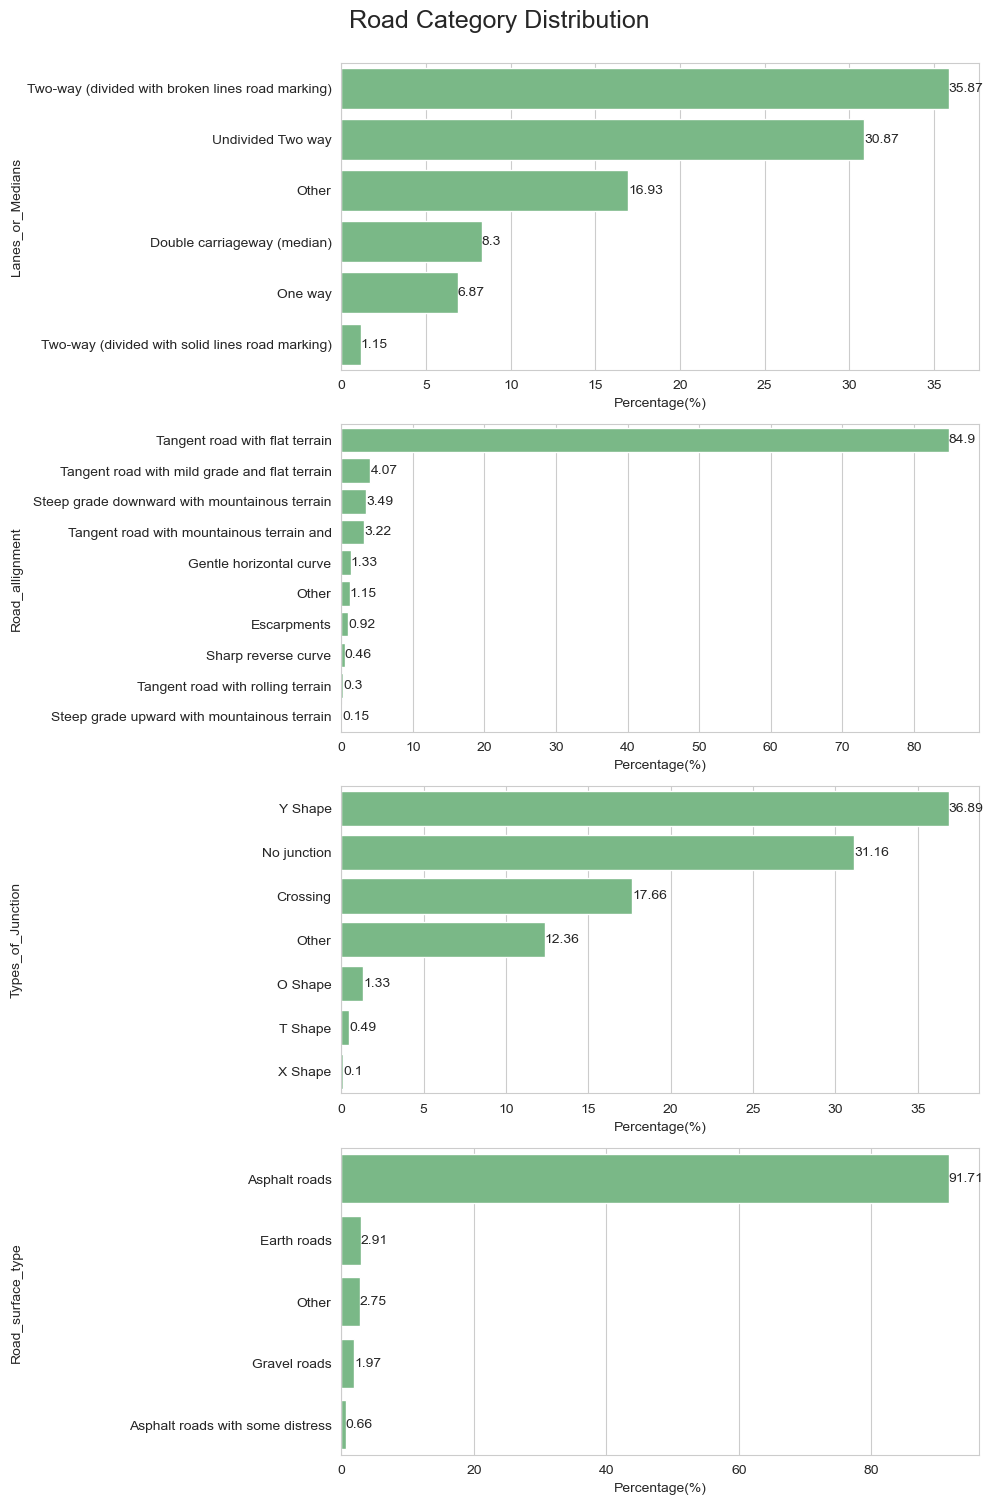

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')
plt.figure(figsize=(10,15), dpi=100)
plt.suptitle('Road Category Distribution', y = 1, fontsize = 18)
for i in range(0, len(road_tables)):
    plt.subplot(4, 1, i+1)
    ax = sns.barplot(
        y = road_tables[i][road[i]],
        x = 100*(round(road_tables[i]['count'] / road_tables[i]['count'].sum(),4)),
        width=0.8,
        color='#6FC381'
    )
    for container in ax.containers:
        ax.bar_label(container) # type: ignore
    ax.yaxis.set_label_coords(-0.5,0.5)
    plt.tight_layout()
    plt.xlabel('Percentage(%)')
plt.show()

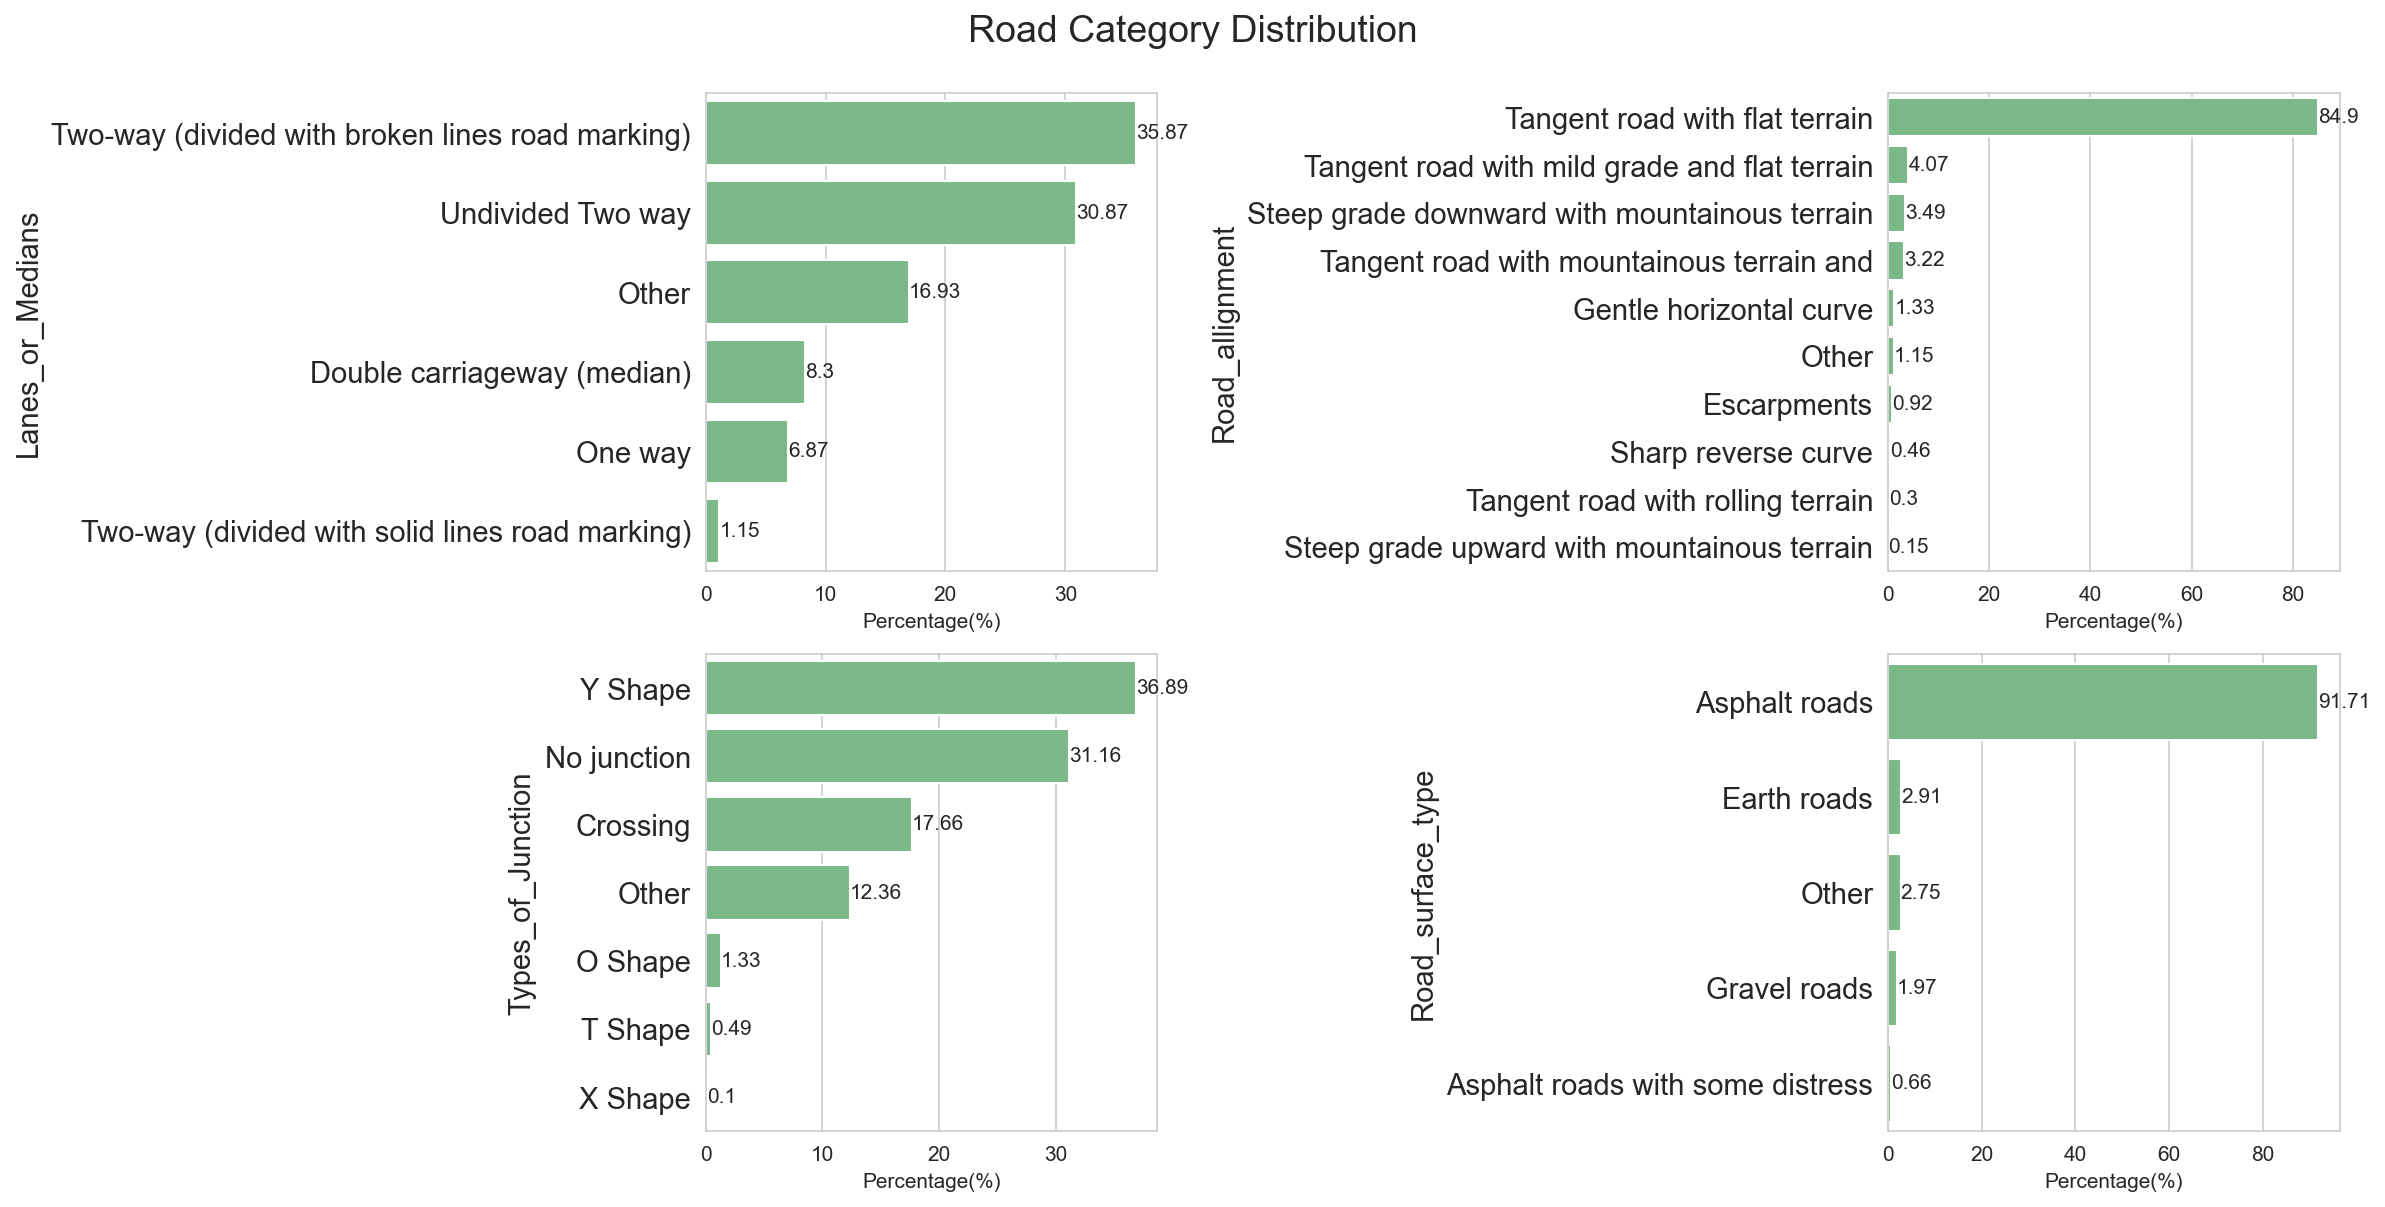

In [32]:
sns.set_style('whitegrid')
plt.figure(figsize=(16,8), dpi=150)
plt.suptitle('Road Category Distribution', y = 1, fontsize = 18)
for i in range(0, len(road_tables)):
    plt.subplot(2, 2, i+1)
    ax = sns.barplot(
        y = road_tables[i][road[i]],
        x = 100*(round(road_tables[i]['count'] / road_tables[i]['count'].sum(),4)),
        width=0.8,
        color='#6FC381'
    )
    for container in ax.containers:
        ax.bar_label(container) # type: ignore
    plt.yticks(fontsize = 14)
    plt.ylabel(ylabel = road[i], fontsize = 14)
    plt.tight_layout()
    plt.xlabel('Percentage(%)')
plt.show()

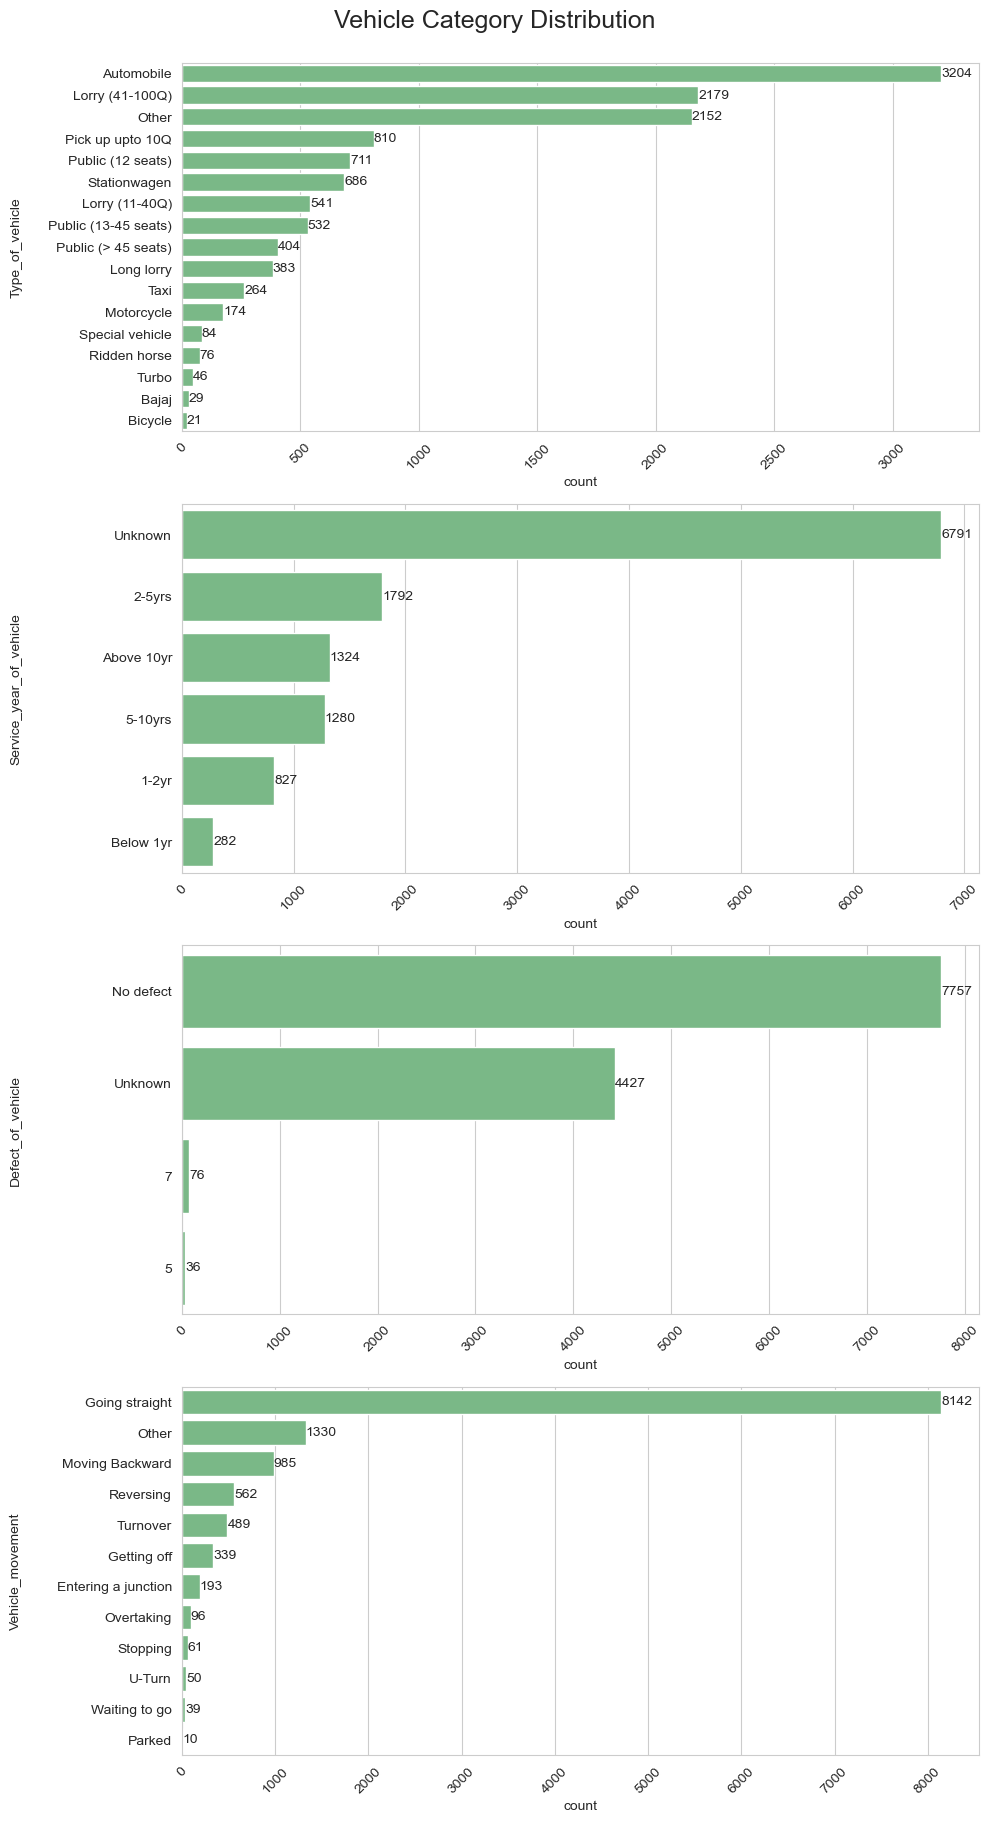

In [33]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,18), dpi=100)
plt.suptitle('Vehicle Category Distribution', y = 1, fontsize = 18)
for i in range(0, len(vehicle)):
    plt.subplot(len(vehicle), 1, i+1)
    ax = sns.barplot(
        y = vehicle_tables[i][vehicle[i]],
        x = vehicle_tables[i]['count'],
        color = '#6FC381',
        width=0.8
    )
    for container in ax.containers:
        ax.bar_label(container) # type: ignore
    ax.yaxis.set_label_coords(-0.2,0.5)
    plt.tight_layout()
    plt.xticks(rotation = 45)
plt.show()

In [18]:
from matplotlib import colors
color_map = colors.LinearSegmentedColormap.from_list('custom', ['#B2DFBC', '#6A352F'])
color_map_inverse = colors.LinearSegmentedColormap.from_list('custom', ['#6A352F', '#B2DFBC'])
color_map2 = colors.LinearSegmentedColormap.from_list('custom', ['#B2DFBC', '#3D3D3D'])
color_map2_inverse = colors.LinearSegmentedColormap.from_list('custom', ['#3D3D3D', '#B2DFBC'])
color_map3 = colors.LinearSegmentedColormap.from_list('custom', ['#B2DFBC', '#3D3D3D', '#441E1A'])
color_map4 = colors.ListedColormap(['#A3D0AD', '#9DB379', '#909548', '#7A6638', '#441E1A'])
color_map5 = colors.ListedColormap(['#72C083', '#ACCA75', '#C9CF6E', '#E6D367', '#B09D50', '#7a6638', '#5d2823'])
color_map6 = colors.ListedColormap(['#72C083', '#B6C185', '#B8B35C', '#958f4a', '#7a6638', '#5d2823'])

In [19]:
accident_order = ['Slight Injury', 'Serious Injury', 'Fatal injury']

In [20]:
accident['Death_occured'] = (accident['Casualty_class'] != 'NA')

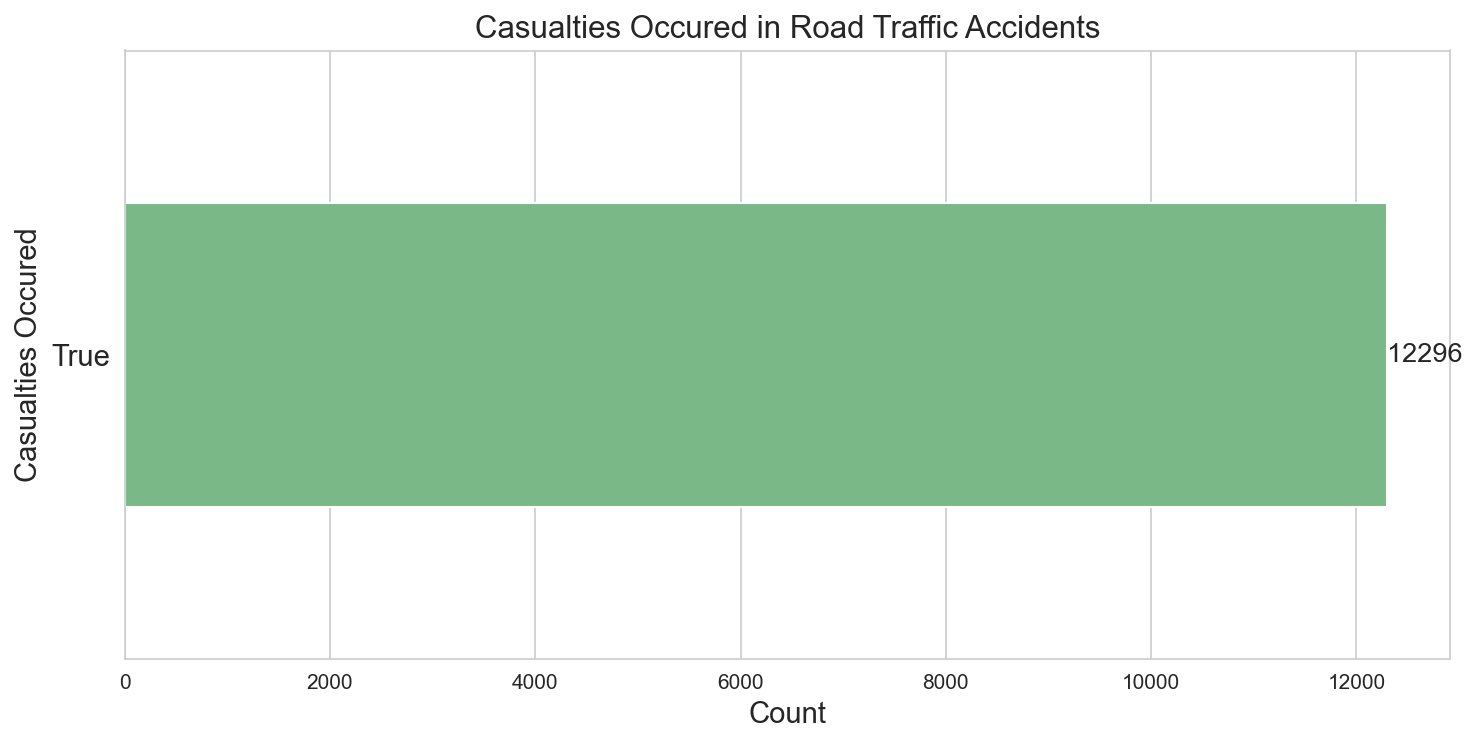

In [21]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,5), dpi=150)
plt.title('Casualties Occured in Road Traffic Accidents', fontsize = 15)
ax = sns.countplot(
        y = accident['Death_occured'],
        width=0.5,
        color='#6FC381'
    )
for container in ax.containers:
    ax.bar_label(container, fontsize = 13) # type: ignore
plt.yticks(fontsize = 14)
plt.ylabel(ylabel = 'Casualties Occured', fontsize = 14)
plt.tight_layout()
plt.xlabel('Count', fontsize = 14)
plt.show()

In [22]:
4435 / (4435 + 7861)

0.3606864020819779

In [23]:
accident[['Number_of_vehicles_involved', 'Number_of_casualties']] = accident[['Number_of_vehicles_involved', 'Number_of_casualties']].astype(int)

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
accident['Single_pileup_collision'] = np.where(accident['Number_of_vehicles_involved'] > 2, '>2', [x for x in accident['Number_of_vehicles_involved'].values])
accident['Hour of day'] = accident['Time'].dt.hour

sns.set_style('whitegrid')

plt.figure(figsize=(6,6), dpi = 120)
plt.title('Time Accident Distribution and The Number of Vehicle Involved')
plt.hist([accident[accident['Single_pileup_collision'] == '>2']['Hour_of_day'],
          accident[accident['Single_pileup_collision'] == '1']['Hour_of_day'],
          accident[accident['Single_pileup_collision'] == '2']['Hour_of_day']], 
          color= ['#6A352F','#8B826F','#6FC381'],
          bins=24,
          stacked=True, 
          alpha=0.8)
plt.legend(['>2', '1', '2'], title = 'Number of Vehicle Involved')
plt.xlabel('Time (Hours)')
plt.xticks(list(range(0,24,3)))
plt.show()

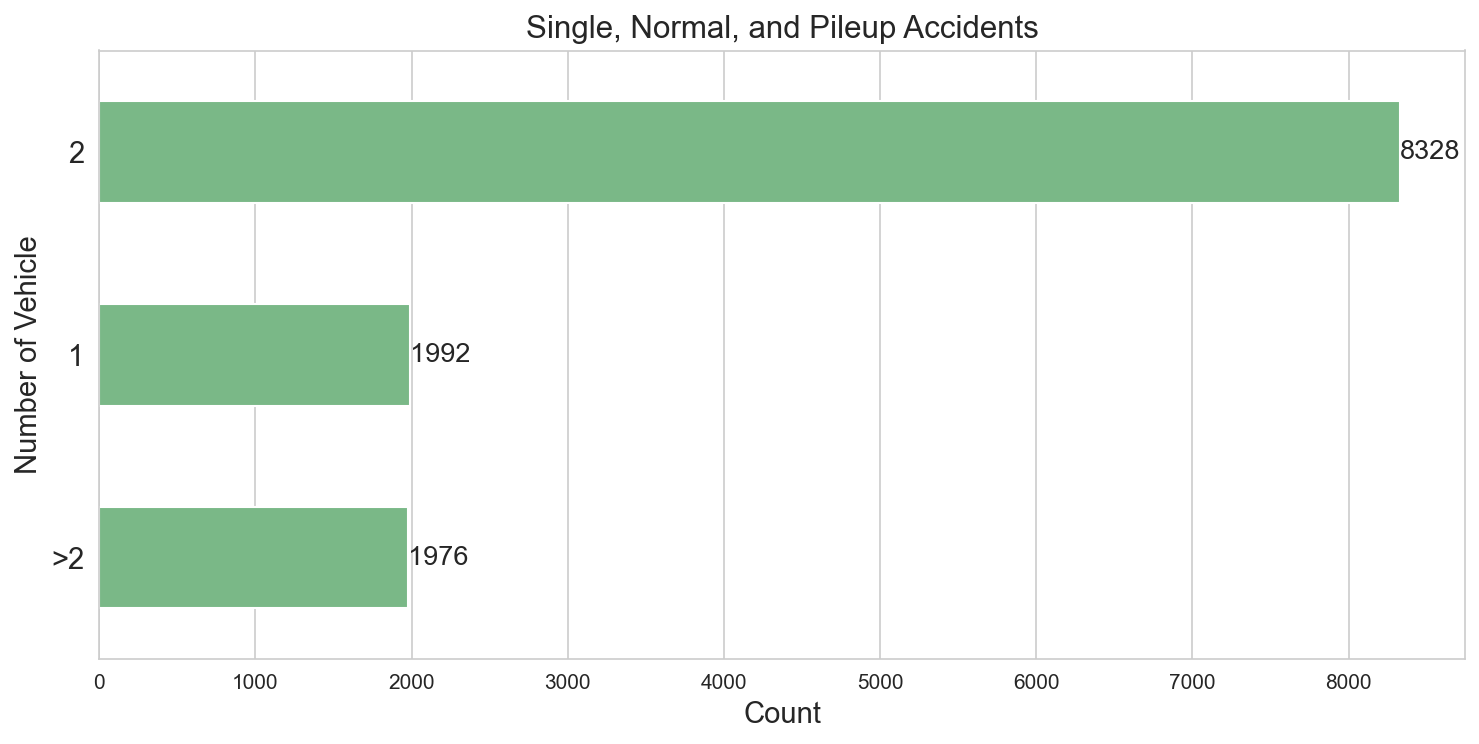

In [28]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,5), dpi=150)
plt.title('Single, Normal, and Pileup Accidents', fontsize = 15)
ax = sns.countplot(
        y = accident['Single_pileup_collision'],
        width=0.5,
        color='#6FC381'
    )
for container in ax.containers:
    ax.bar_label(container, fontsize = 13) # type: ignore
plt.yticks(fontsize = 14)
plt.ylabel(ylabel = 'Number of Vehicle', fontsize = 14)
plt.tight_layout()
plt.xlabel('Count', fontsize = 14)
plt.show()

In [29]:
accident['Weekday-weekend'] = np.where(accident['Day_of_week'].isin(['Saturday','Sunday']), 'Weekend', 'Weekday')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [30]:
day_severity = accident.groupby(['Day_of_week', 'Accident_severity'])['Time'].count().reset_index().sort_values(by = 'Time', ascending=False).rename(columns={'Time':'count'})
day_severity['percent'] = 100*(round(day_severity['count'] / day_severity['count'].sum(), 4))
day_severity_pivot = day_severity.pivot_table(index='Day_of_week', columns= 'Accident_severity', values='percent', fill_value = 0)
day_severity_pivot = day_severity_pivot.reindex(day_order)
day_severity_pivot = day_severity_pivot.reindex(accident_order, axis= 1)

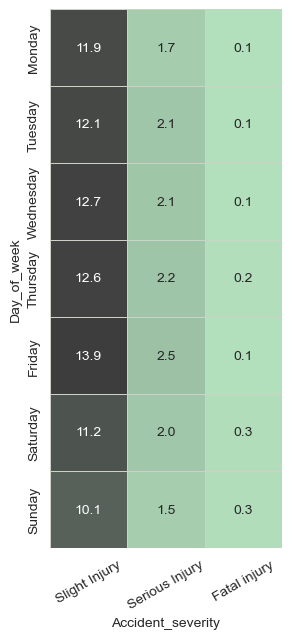

In [31]:
plt.figure(figsize=(3,7))
sns.heatmap(day_severity_pivot, 
            cmap= color_map2, 
            vmax = 13, 
            annot=True, 
            fmt= '.1f', 
            linewidths=0.5, 
            linecolor='#CFD1C7', 
            cbar=False)
plt.xticks(rotation = 30)
plt.show()